<a href="https://colab.research.google.com/github/Uchihatt/My-Projects/blob/main/S%26P_500_(2010_2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing values in price matrix: 721
Daily returns shape: (3454, 9)

First few rows of returns:
 Ticker          AAPL      AMZN      AVGO      GOOG     GOOGL      META  \
Date                                                                     
2012-05-21  0.058260  0.019921  0.029647  0.022835  0.022835 -0.109861   
2012-05-22 -0.007679 -0.012746  0.011647 -0.021674 -0.021674 -0.089039   
2012-05-23  0.024399  0.009056  0.071954  0.014414  0.014414  0.032258   
2012-05-24 -0.009183 -0.009389 -0.030131 -0.009517 -0.009517  0.032188   
2012-05-25 -0.005360 -0.010918  0.019686 -0.020094 -0.020094 -0.033909   

Ticker          MSFT      NVDA      TSLA  
Date                                      
2012-05-21  0.016399  0.017385  0.043904  
2012-05-22  0.000336 -0.012205  0.070559  
2012-05-23 -0.021841  0.024712  0.007143  
2012-05-24 -0.001374 -0.026527 -0.023855  
2012-05-25 -0.000344  0.023947 -0.015522  

=== Optimal Portfolios ===
Max Sharpe Ratio: Return=0.4546, Volatility=0.3173, Shar

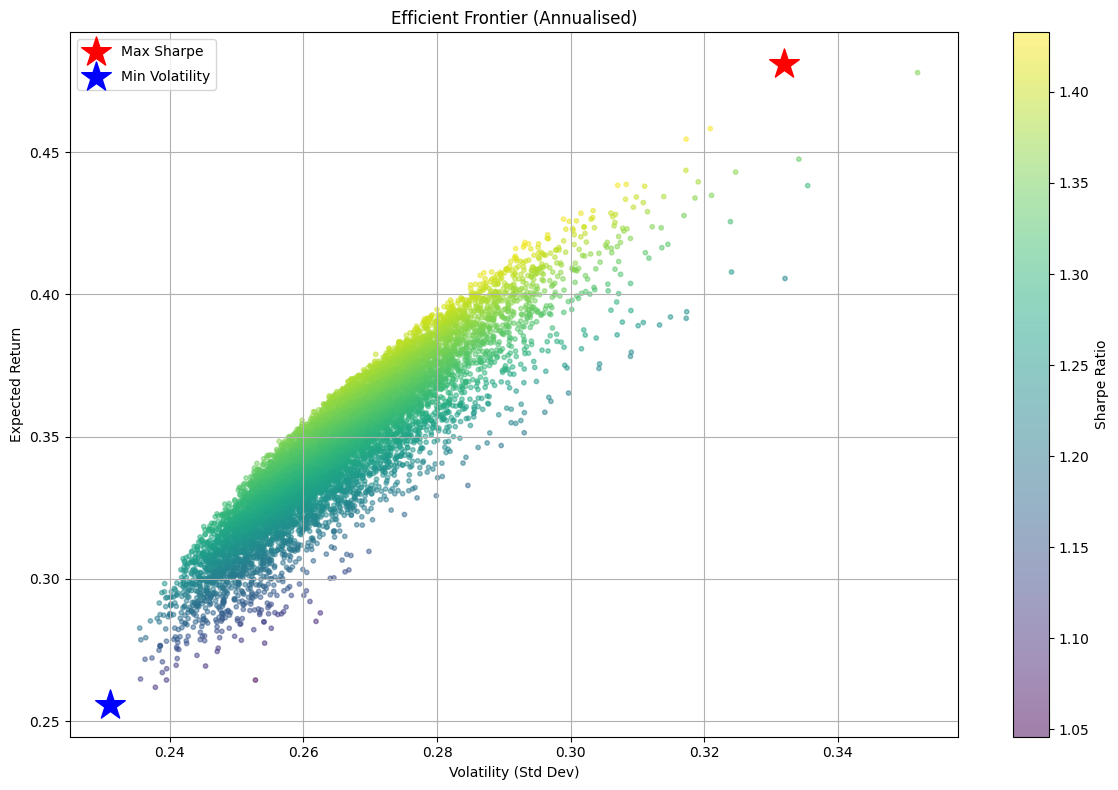


Max Sharpe Portfolio Weights:
AAPL: 0.0000
AMZN: 0.0000
AVGO: 0.2902
GOOG: 0.1631
GOOGL: 0.0000
META: 0.0000
MSFT: 0.0000
NVDA: 0.3695
TSLA: 0.1772

Min Volatility Portfolio Weights:
AAPL: 0.2703
AMZN: 0.0695
AVGO: 0.0365
GOOG: 0.1336
GOOGL: 0.1337
META: 0.0072
MSFT: 0.3491
NVDA: 0.0000
TSLA: 0.0000


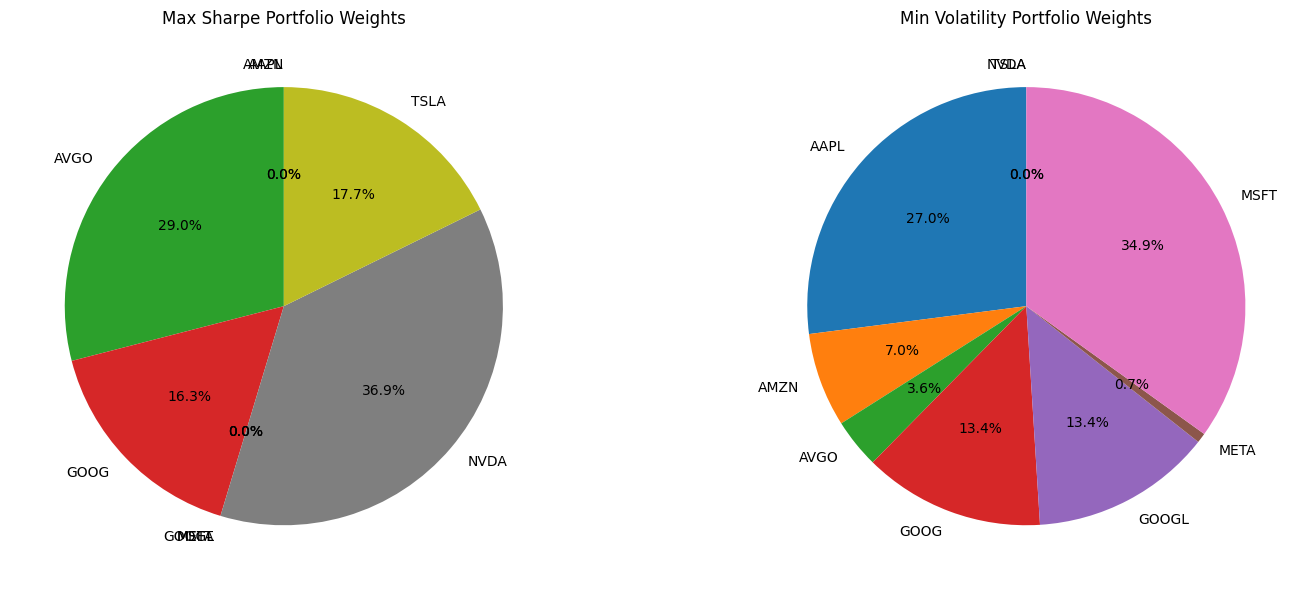

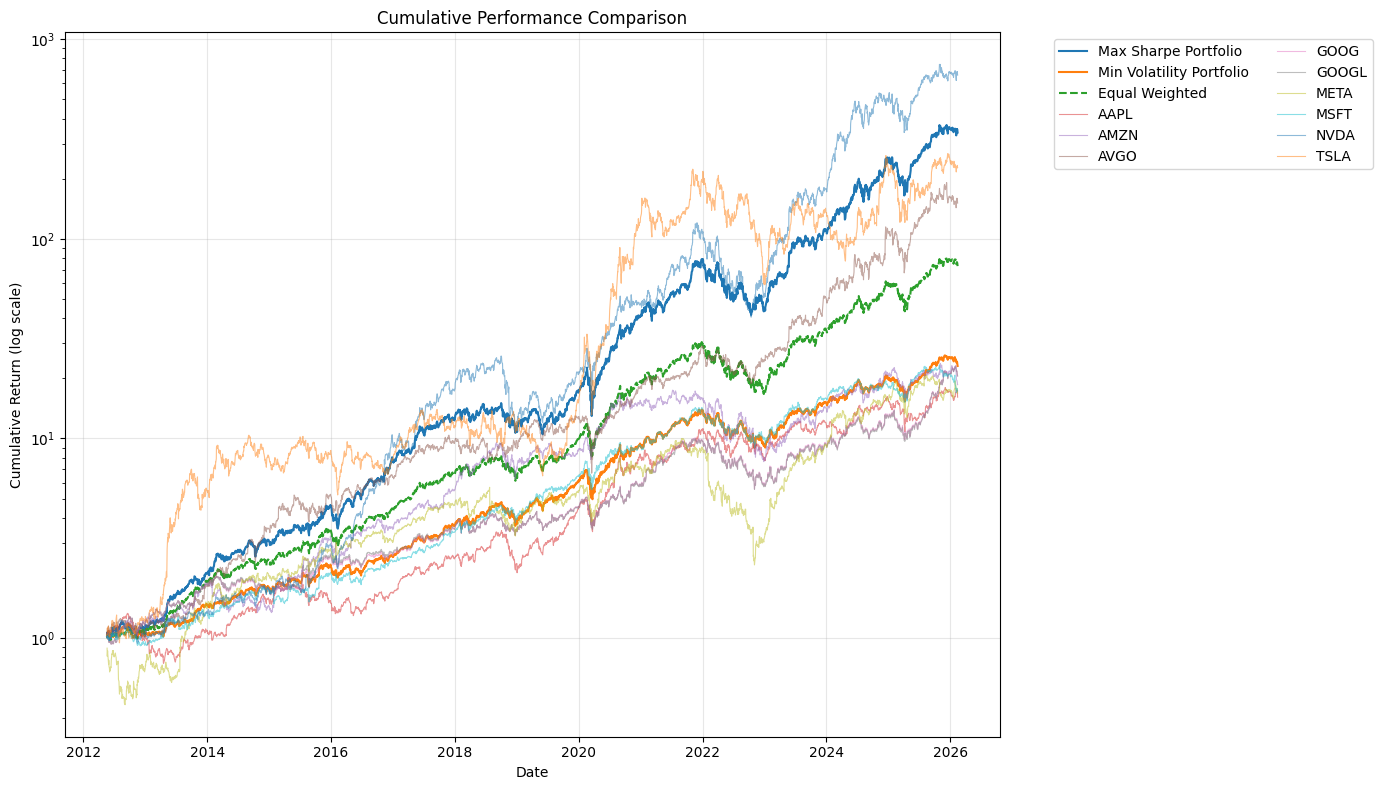

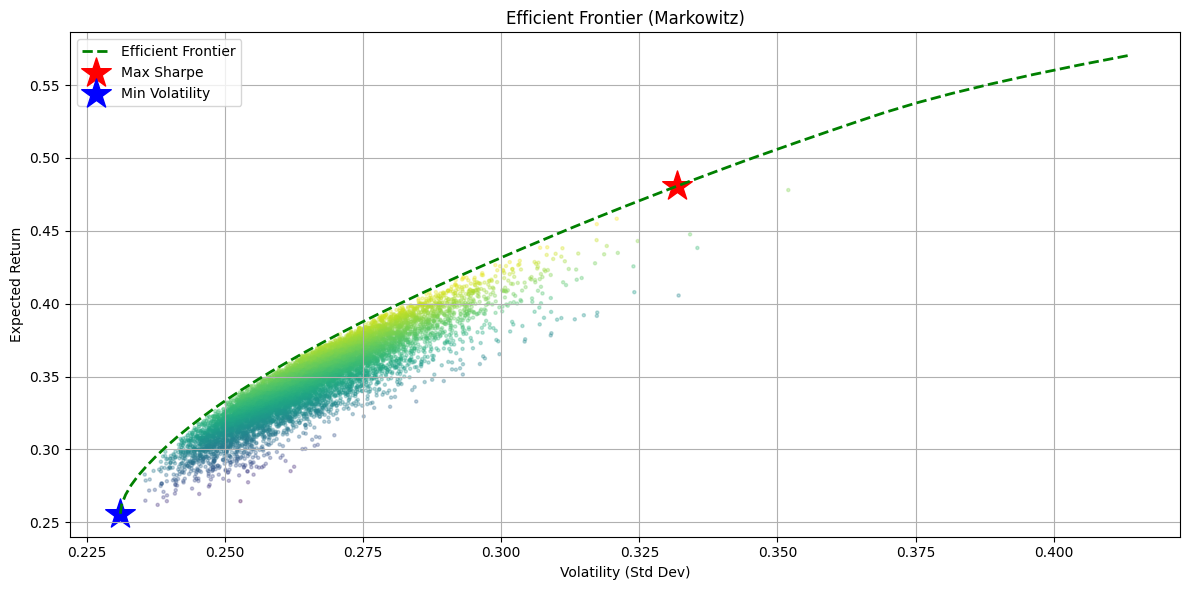

In [1]:
# ============================================================================
# OPTIMAL PORTFOLIO CONSTRUCTION (MARKOWITZ) FOR TOP 10 S&P 500 STOCKS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

# ------------------------------
# 1. Load and prepare data
# ------------------------------
PATH = "/content/sp500_top10_stocks_clean.csv"
df = pd.read_csv(PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Use adjusted close for returns (splits & dividends adjusted)
# Pivot to have dates as index, tickers as columns
prices = df.pivot(index="Date", columns="Ticker", values="Adj_Close")
# Check for missing values
print("Missing values in price matrix:", prices.isnull().sum().sum())

# Calculate daily returns (simple returns)
returns = prices.pct_change().dropna()  # removes first row with NaN

print("Daily returns shape:", returns.shape)
print("\nFirst few rows of returns:\n", returns.head())

# ------------------------------
# 2. Compute annualized returns and covariance
# ------------------------------
# Assume 252 trading days per year
annual_returns = returns.mean() * 252
annual_cov = returns.cov() * 252

# ------------------------------
# 3. Portfolio statistics functions
# ------------------------------
def portfolio_annual_performance(weights, mean_returns, cov_matrix):
    """Calculate portfolio return and volatility."""
    port_return = np.sum(mean_returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol

def random_portfolios(num_portfolios, mean_returns, cov_matrix, risk_free_rate=0.0):
    """Generate random portfolios and compute return, volatility, Sharpe ratio."""
    results = np.zeros((3, num_portfolios))
    weights_record = []
    num_assets = len(mean_returns)
    for i in range(num_portfolios):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)  # normalize
        weights_record.append(weights)
        port_return, port_vol = portfolio_annual_performance(weights, mean_returns, cov_matrix)
        sharpe = (port_return - risk_free_rate) / port_vol
        results[0, i] = port_return
        results[1, i] = port_vol
        results[2, i] = sharpe
    return results, weights_record

# ------------------------------
# 4. Generate random portfolios
# ------------------------------
num_portfolios = 10000
risk_free_rate = 0.0  # assume 0% for Sharpe calculation

results, weights_record = random_portfolios(num_portfolios, annual_returns, annual_cov, risk_free_rate)

# ------------------------------
# 5. Find optimal portfolios
# ------------------------------
# Max Sharpe
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_vol = results[1, max_sharpe_idx]
max_sharpe_weights = weights_record[max_sharpe_idx]

# Min volatility
min_vol_idx = np.argmin(results[1])
min_vol_return = results[0, min_vol_idx]
min_vol_vol = results[1, min_vol_idx]
min_vol_weights = weights_record[min_vol_idx]

print("\n=== Optimal Portfolios ===")
print(f"Max Sharpe Ratio: Return={max_sharpe_return:.4f}, Volatility={max_sharpe_vol:.4f}, Sharpe={results[2,max_sharpe_idx]:.4f}")
print(f"Min Volatility:    Return={min_vol_return:.4f}, Volatility={min_vol_vol:.4f}")

# ------------------------------
# 6. Efficient frontier via optimization
# ------------------------------
def neg_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    p_ret, p_vol = portfolio_annual_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_vol

def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_annual_performance(weights, mean_returns, cov_matrix)[1]

num_assets = len(annual_returns)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
initial_guess = num_assets * [1. / num_assets]

# Find tangency portfolio (max Sharpe)
opt_sharpe = minimize(neg_sharpe, initial_guess,
                      args=(annual_returns, annual_cov, risk_free_rate),
                      method='SLSQP', bounds=bounds, constraints=constraints)
if opt_sharpe.success:
    opt_sharpe_weights = opt_sharpe.x
    opt_sharpe_return, opt_sharpe_vol = portfolio_annual_performance(opt_sharpe_weights, annual_returns, annual_cov)
    print("\nOptimization-based Max Sharpe weights (should be close to random):")
else:
    print("\nOptimization failed, using random portfolio result.")

# Find min volatility portfolio
opt_minvol = minimize(portfolio_volatility, initial_guess,
                      args=(annual_returns, annual_cov),
                      method='SLSQP', bounds=bounds, constraints=constraints)
if opt_minvol.success:
    opt_minvol_weights = opt_minvol.x
    opt_minvol_return, opt_minvol_vol = portfolio_annual_performance(opt_minvol_weights, annual_returns, annual_cov)
    print("\nOptimization-based Min Volatility weights (should be close to random):")
else:
    print("\nOptimization failed, using random portfolio result.")

# Use optimized weights if available, else keep random
if opt_sharpe.success:
    max_sharpe_weights = opt_sharpe_weights
    max_sharpe_return, max_sharpe_vol = opt_sharpe_return, opt_sharpe_vol
if opt_minvol.success:
    min_vol_weights = opt_minvol_weights
    min_vol_return, min_vol_vol = opt_minvol_return, opt_minvol_vol

# ------------------------------
# 7. Visualisation
# ------------------------------
plt.figure(figsize=(12, 8))
# Scatter random portfolios
scatter = plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
# Mark optimal portfolios
plt.scatter(max_sharpe_vol, max_sharpe_return, marker='*', color='r', s=500, label='Max Sharpe')
plt.scatter(min_vol_vol, min_vol_return, marker='*', color='b', s=500, label='Min Volatility')
plt.title('Efficient Frontier (Annualised)')
plt.xlabel('Volatility (Std Dev)')
plt.ylabel('Expected Return')
plt.legend(labelspacing=0.8)
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------
# 8. Display weights
# ------------------------------
def print_weights(weights, tickers, name):
    print(f"\n{name} Portfolio Weights:")
    for t, w in zip(tickers, weights):
        print(f"{t}: {w:.4f}")

tickers = returns.columns.tolist()
print_weights(max_sharpe_weights, tickers, "Max Sharpe")
print_weights(min_vol_weights, tickers, "Min Volatility")

# Pie charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.pie(max_sharpe_weights, labels=tickers, autopct='%1.1f%%', startangle=90)
ax1.set_title('Max Sharpe Portfolio Weights')
ax2.pie(min_vol_weights, labels=tickers, autopct='%1.1f%%', startangle=90)
ax2.set_title('Min Volatility Portfolio Weights')
plt.tight_layout()
plt.show()

# ------------------------------
# 9. Cumulative performance comparison
# ------------------------------
# Compute cumulative returns of each optimal portfolio and individual stocks
# Reconstruct daily portfolio returns
daily_returns_portfolio_maxsharpe = returns.dot(max_sharpe_weights)
daily_returns_portfolio_minvol = returns.dot(min_vol_weights)

cumulative_maxsharpe = (1 + daily_returns_portfolio_maxsharpe).cumprod()
cumulative_minvol = (1 + daily_returns_portfolio_minvol).cumprod()
# Also compute equal-weighted portfolio for comparison
equal_weights = np.ones(num_assets) / num_assets
cumulative_equal = (1 + returns.dot(equal_weights)).cumprod()

# Plot
plt.figure(figsize=(14, 8))
plt.plot(cumulative_maxsharpe.index, cumulative_maxsharpe, label='Max Sharpe Portfolio', linewidth=1.5)
plt.plot(cumulative_minvol.index, cumulative_minvol, label='Min Volatility Portfolio', linewidth=1.5)
plt.plot(cumulative_equal.index, cumulative_equal, label='Equal Weighted', linewidth=1.5, linestyle='--')
# Also plot best and worst single stock for context
stock_cumulative = (1 + returns).cumprod()
for col in stock_cumulative.columns:
    plt.plot(stock_cumulative.index, stock_cumulative[col], label=col, alpha=0.5, linewidth=0.8)
plt.title('Cumulative Performance Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (log scale)')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------
# 10. Additional: efficient frontier curve (optional)
# ------------------------------
# Generate a range of target returns and find minimum variance for each
target_returns = np.linspace(min_vol_return, max_sharpe_return * 1.2, 50)
frontier_vols = []
for ret in target_returns:
    constraints_frontier = (
        {'type': 'eq', 'fun': lambda x: portfolio_annual_performance(x, annual_returns, annual_cov)[0] - ret},
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    )
    opt = minimize(portfolio_volatility, initial_guess, args=(annual_returns, annual_cov),
                   method='SLSQP', bounds=bounds, constraints=constraints_frontier)
    if opt.success:
        frontier_vols.append(opt.fun)
    else:
        frontier_vols.append(np.nan)

plt.figure(figsize=(12, 6))
plt.plot(frontier_vols, target_returns, 'g--', linewidth=2, label='Efficient Frontier')
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=5, alpha=0.3)
plt.scatter(max_sharpe_vol, max_sharpe_return, marker='*', color='r', s=500, label='Max Sharpe')
plt.scatter(min_vol_vol, min_vol_return, marker='*', color='b', s=500, label='Min Volatility')
plt.title('Efficient Frontier (Markowitz)')
plt.xlabel('Volatility (Std Dev)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()